In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ---------------------------------------------------------
# CELL STYLE CONFIGURATION
# ---------------------------------------------------------
# Set global font properties for "Cell" style (Arial/Helvetica)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.linewidth'] = 1.5      # Thicker axes
mpl.rcParams['xtick.major.width'] = 1.5   # Thicker ticks
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['xtick.direction'] = 'out'   # Ticks pointing out
mpl.rcParams['ytick.direction'] = 'out'

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# File paths (Replace these with your actual file paths)
files = {
    '2M': '../new_mageck/Syn1-ND-all_2M/Syn1-ND-all_2M.sgrna_summary.txt',
    '4M': '../new_mageck/Syn1-ND-all_4M/Syn1-ND-all_4M.sgrna_summary.txt',
}

In [18]:
df_2m = pd.read_csv('../new_mageck/Syn1-ND-all_2M/Syn1-ND-all_2M.gene_summary.txt', sep='\t')
hits_2m = df_2m[df_2m['hits'] == -1]['gene'].tolist()
df_4m = pd.read_csv('../new_mageck/Syn1-ND-all_4M/Syn1-ND-all_4M.gene_summary.txt', sep='\t')
hits_4m = df_4m[df_4m['hits'] == -1]['gene'].tolist()

# List of your hit genes to highlight
hit_genes_1= hits_4m
hit_genes_2= hits_4m

# Non-targeting control prefix (standard in libraries is usually "NonTargeting" or "Safe_")
ntc_prefix = 'non-targeting'
lfc_col = 'LFC' 
score_col = 'score' # <--- Column name to sort by (e.g. 'score', 'efficiency', etc.)
STD_FONT_SIZE = 16

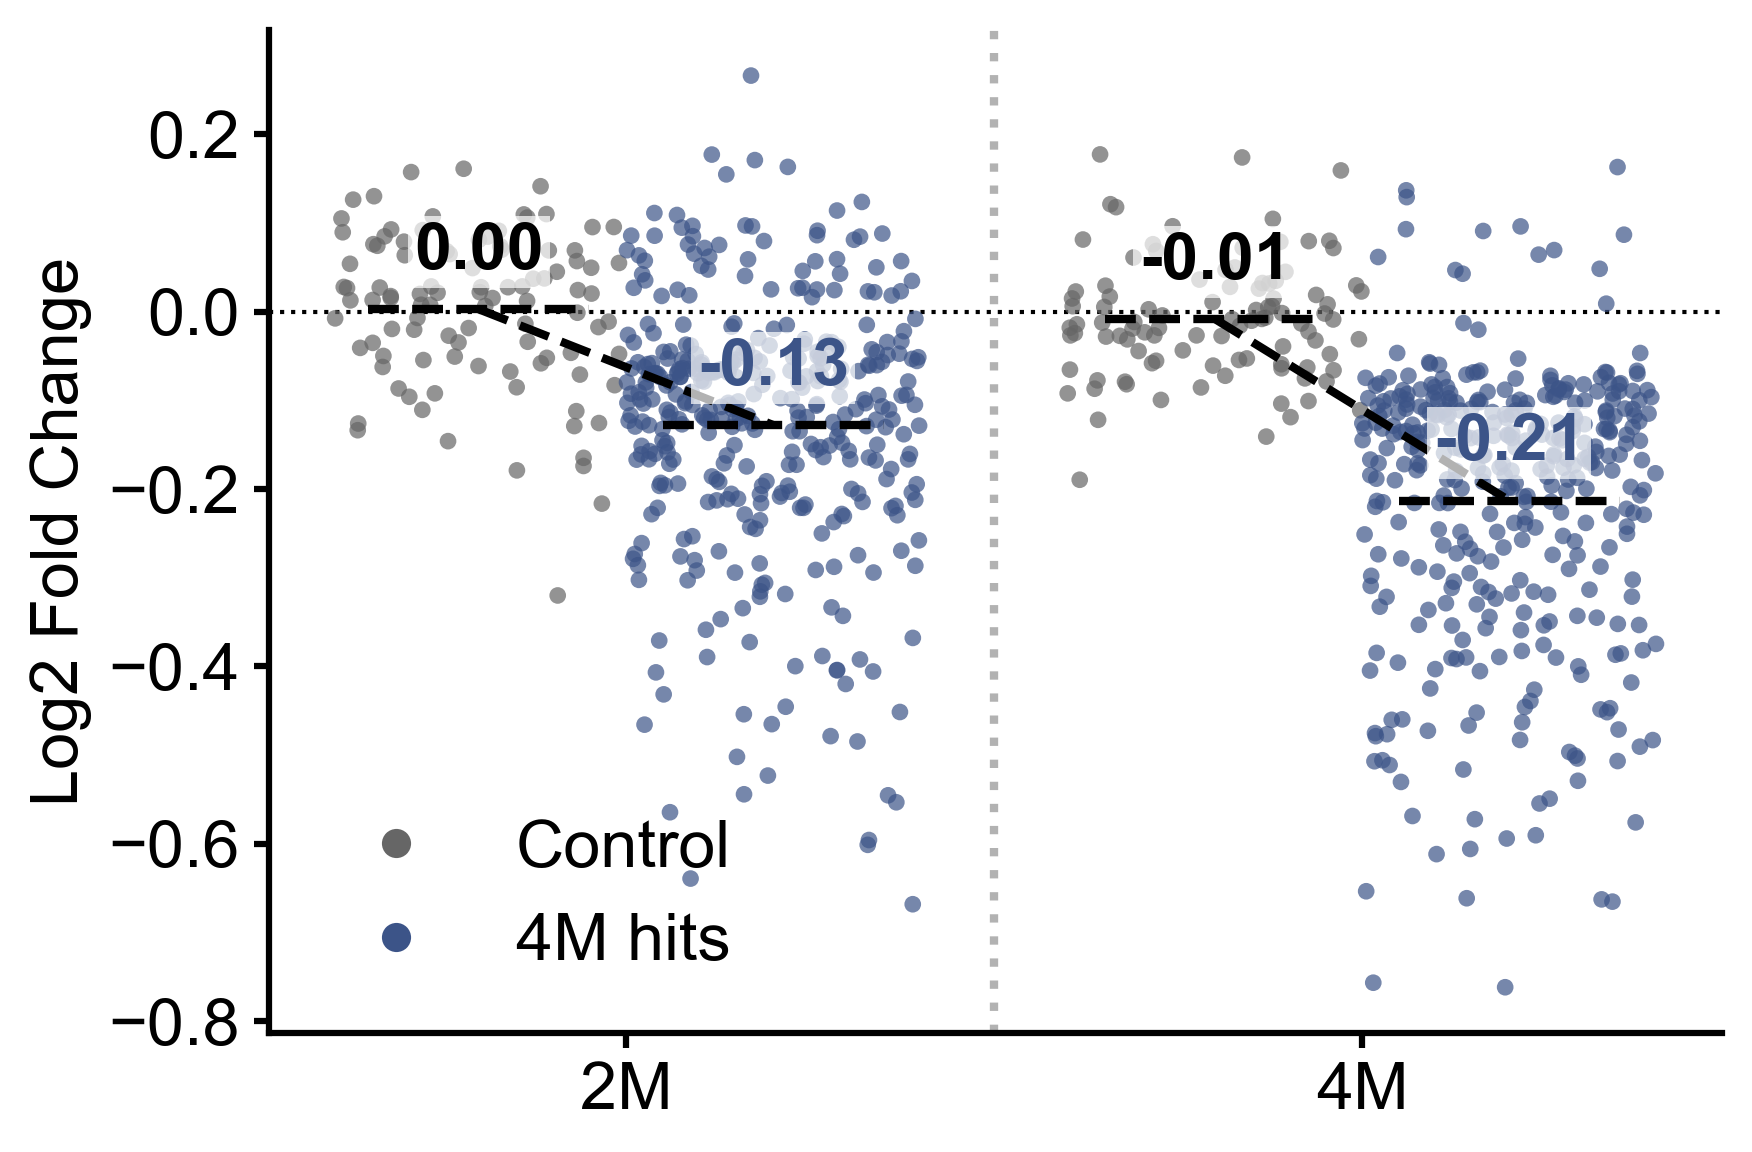

In [19]:
plot_data = []

def process_gene_list(df, gene_list, category_name, timepoint):
    """Helper function to process a list of genes"""
    hits_df = df[df['Gene'].isin(gene_list)].copy()
    selected = []

    if score_col not in df.columns:
        # Fallback if no score column (just take top 3 by LFC magnitude as rough default)
        for gene in gene_list:
            g_data = hits_df[hits_df['Gene'] == gene].copy()
            g_data['abs_tmp'] = g_data[lfc_col].abs()
            selected.append(g_data.sort_values('abs_tmp', ascending=False).head(3))
    else:
        # Sort by Score
        for gene in gene_list:
            g_data = hits_df[hits_df['Gene'] == gene].copy()
            selected.append(g_data.sort_values(score_col, ascending=False).head(3))

    if selected:
        final = pd.concat(selected)
        final['Category'] = category_name
        final['Timepoint'] = timepoint
        return final[['sgrna', 'Gene', lfc_col, 'Category', 'Timepoint']]
    return pd.DataFrame()

for timepoint, file_path in files.items():
    try:
        df = pd.read_csv(file_path, sep='\t')
    except FileNotFoundError:
        continue

    # 1. Process Controls
    ntc_df = df[df['Gene'].str.startswith(ntc_prefix)].copy()
    ntc_df['Category'] = 'Control'
    ntc_df['Timepoint'] = timepoint
    plot_data.append(ntc_df[['sgrna', 'Gene', lfc_col, 'Category', 'Timepoint']])

    # 2. Process Target Set 1
    set1_df = process_gene_list(df, hit_genes_1, 'Target Set 1', timepoint)
    if not set1_df.empty:
        plot_data.append(set1_df)

# No need to process Target Set 2, so this section is removed.

if not plot_data:
    print("No data found.")
else:
    final_df = pd.concat(plot_data)

    # ---------------------------------------------------------
    # PLOTTING
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 4), dpi=300)  # Slightly wider for 1 group

    # Define Categories Order and Colors
    hue_order = ['Control', 'Target Set 1']
    colors = {
        'Control': '#666666', 
        'Target Set 1': '#3C5488FF',  # Red
    }

    # 1. Draw Vertical Grid Separators
    num_timepoints = len(files.keys())
    for i in range(num_timepoints - 1):
        plt.axvline(x=i + 0.5, color='grey', linestyle=':', linewidth=2, alpha=0.6, zorder=0)

    # 2. Create Stripplot
    ax = sns.stripplot(
        data=final_df,
        x='Timepoint',
        y=lfc_col,
        hue='Category',
        hue_order=hue_order,
        palette=colors,
        dodge=True,
        jitter=0.4,
        size=4,
        alpha=0.7,
        edgecolor='none',
        zorder=2,
        legend=False
    )

    # 3. Add Mean Lines and Labels
    category_offsets = {
        'Control': -0.2,
        'Target Set 1': 0.2
    }

    box_style = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
    y_offset = (final_df[lfc_col].max() - final_df[lfc_col].min()) * 0.03
    mean_values = {}  

    for timepoint_idx, timepoint in enumerate(files.keys()):
        if timepoint not in final_df['Timepoint'].values: continue
        
        for cat in hue_order:
            subset = final_df[(final_df['Timepoint'] == timepoint) & (final_df['Category'] == cat)]
            if subset.empty: continue
            
            mean_val = subset[lfc_col].mean()
            x_pos = timepoint_idx + category_offsets[cat]
            
            # Mean Line
            plt.hlines(y=mean_val, xmin=x_pos - 0.15, xmax=x_pos + 0.15, colors='black', 
                       linestyle='--', linewidth=2, zorder=5)
            
            # Store mean values
            if cat == 'Control':
                control_mean = (x_pos, mean_val)
            elif cat == 'Target Set 1':
                target_set_mean = (x_pos, mean_val)
                
            # Label
            font_weight = 'bold' 
            text_color = colors[cat] if cat != 'Control' else 'black'
            
            plt.text(x=x_pos, y=mean_val + y_offset, s=f'{mean_val:.2f}',
                     color=text_color, ha='center', va='bottom', 
                     fontsize=STD_FONT_SIZE, fontweight=font_weight, zorder=10,
                     bbox=box_style)
        if control_mean and target_set_mean:
                # Unpack positions
                plt.plot(
                    [control_mean[0], target_set_mean[0]], 
                    [control_mean[1], target_set_mean[1]], 
                    color='black', linestyle='--', linewidth=2, zorder=6
                )
            
    # Formatting
    plt.axhline(0, color='black', linestyle=':', linewidth=1, zorder=1)
    
    plt.ylabel('Log2 Fold Change', fontsize=STD_FONT_SIZE)
    plt.xlabel('')
    plt.tick_params(axis='both', which='major', labelsize=STD_FONT_SIZE)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Control', markerfacecolor=colors['Control'], markersize=8),
        Line2D([0], [0], marker='o', color='w', label='4M hits', markerfacecolor=colors['Target Set 1'], markersize=8),
    ]
    ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=STD_FONT_SIZE)

    sns.despine(trim=False) 
    plt.tight_layout()
    plt.savefig('../comparison/2M_vs_4M/Syn1_ND_2M_4M_sgRNA_dropout_top3sg.pdf')

In [12]:
hue_order

['Control', 'Target Set 1']